BLOCK 1 — Dataset Loading & Basic Inspection

In [23]:
from tqdm import tqdm

In [24]:
# ==============================
# BLOCK 1 — download & LOAD DATASET
# ==============================

import kagglehub
import glob
import os
import pandas as pd
import numpy as np

# Download dataset
path = kagglehub.dataset_download("dhivyeshrk/diseases-and-symptoms-dataset")
print("Dataset folder:", path)

# Find all CSV files
all_files = glob.glob(os.path.join(path, "**/*"), recursive=True)
csv_files = [f for f in all_files if f.lower().endswith(".csv")]

print("\nCSV files found:", len(csv_files))
for f in csv_files:
    print("-", f)

# Since this dataset has only one CSV, just take the first
if len(csv_files) == 0:
    raise ValueError("No CSV files found in dataset!")

csv_path = csv_files[0]
print("\nUsing CSV:", csv_path)

# Load
df_raw = pd.read_csv(csv_path)

print("\nShape:", df_raw.shape)
print("Number of columns:", len(df_raw.columns))

display(df_raw.head())

Dataset folder: /kaggle/input/datasets/dhivyeshrk/diseases-and-symptoms-dataset

CSV files found: 1
- /kaggle/input/datasets/dhivyeshrk/diseases-and-symptoms-dataset/Final_Augmented_dataset_Diseases_and_Symptoms.csv

Using CSV: /kaggle/input/datasets/dhivyeshrk/diseases-and-symptoms-dataset/Final_Augmented_dataset_Diseases_and_Symptoms.csv

Shape: (246945, 378)
Number of columns: 378


,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


What We Learned from BLOCK 1

Dataset statistics:

Property	Value
Rows	246,945 patients
Columns	378
Label column	diseases
Symptom features	377 symptoms

Example structure:

diseases | anxiety and nervousness | depression | shortness of breath | ...
panic disorder | 1 | 0 | 1 | ...

So the dataset is exactly what we want:

binary symptom vector
→ disease classification

This is ideal for:

Logistic Regression

Linear SVM

Naive Bayes

LightGBM

TabNet

But There Are Three Issues We Must Fix First

This dataset usually contains hidden problems:

1️⃣ Column name formatting

Example:

shortness of breath
sharp chest pain
abnormal involuntary movements

Spaces and inconsistent names will cause issues later.

We must convert them to:

shortness_of_breath
sharp_chest_pain
abnormal_involuntary_movements
2️⃣ Binary integrity

Even though it looks binary, we must confirm:

only 0 and 1 exist

Sometimes augmented datasets contain:

2
-1
0.5
3️⃣ Duplicate symptom columns

Some Kaggle datasets contain:

symptom
symptom.1
symptom.2

These break model training.

BLOCK 2-Column Cleaning + Label Split

In [25]:
# ==============================
# BLOCK 2 — CLEAN COLUMN NAMES
# ==============================

df = df_raw.copy()

# Normalize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^\w]", "", regex=True)
)

print("Cleaned first 10 columns:")
print(df.columns[:10])
print()

print("Cleaned last 10 columns:")
print(df.columns[-10:])
print()


# ==============================
# DETECT LABEL COLUMN
# ==============================

LABEL_COL = "diseases"

if LABEL_COL not in df.columns:
    raise ValueError("Label column not found!")

print("Label column:", LABEL_COL)


# ==============================
# SPLIT FEATURES AND LABEL
# ==============================

X = df.drop(columns=[LABEL_COL])
y = df[LABEL_COL].astype(str).str.strip().str.lower()

print("\nFeature matrix shape:", X.shape)
print("Label vector length:", len(y))

print("\nNumber of unique diseases:", y.nunique())

print("\nExample diseases:")
print(y.unique()[:10])

Cleaned first 10 columns:
Index(['diseases', 'anxiety_and_nervousness', 'depression',
       'shortness_of_breath', 'depressive_or_psychotic_symptoms',
       'sharp_chest_pain', 'dizziness', 'insomnia',
       'abnormal_involuntary_movements', 'chest_tightness'],
      dtype='object')

Cleaned last 10 columns:
Index(['stuttering_or_stammering', 'problems_with_orgasm', 'nose_deformity',
       'lump_over_jaw', 'sore_in_nose', 'hip_weakness', 'back_swelling',
       'ankle_stiffness_or_tightness', 'ankle_weakness', 'neck_weakness'],
      dtype='object')

Label column: diseases

Feature matrix shape: (246945, 377)
Label vector length: 246945

Number of unique diseases: 773

Example diseases:
['panic disorder' 'vocal cord polyp' 'turner syndrome' 'cryptorchidism'
 'poisoning due to ethylene glycol' 'atrophic vaginitis'
 'fracture of the hand' 'cellulitis or abscess of mouth'
 'eye alignment disorder' 'headache after lumbar puncture']


Dataset Status After BLOCK 2
Clean column names ✅

Example:

shortness_of_breath
abnormal_involuntary_movements
chest_tightness

Good — this will avoid problems later in:

LightGBM

SHAP

feature importance

LLM explanations

Key Dataset Properties
Property	Value
Patients	246,945
Symptoms	377
Diseases	773 classes

This is a large multiclass medical dataset.

But it also means:

246k samples
773 diseases

Average samples per disease ≈ 319

But the distribution will be very long-tailed, meaning:

some diseases = thousands of samples
many diseases = <10 samples

Which is exactly why we planned:

hierarchical classification

prototype retrieval

abstention

Next Step (Very Important)

Now we must verify the dataset integrity.

We need to answer these questions:

1️⃣ Are symptoms strictly binary (0/1)?
2️⃣ Are there invalid values?
3️⃣ Are there constant features (always 0)?
4️⃣ Are there duplicate columns?
5️⃣ How sparse are patient symptom vectors?

This step determines:

how well LR / SVM / NB will work

whether TabNet will struggle

how meaningful SHAP explanations will be

BLOCK 3 — Dataset Integrity Check

In [26]:
# ==============================
# BLOCK 3 — DATA INTEGRITY CHECK
# ==============================

import numpy as np

# ---------- 1️⃣ Check binary values ----------
unique_values = pd.unique(X.values.ravel())
print("Unique values found in symptom matrix:")
print(sorted(unique_values)[:20])

non_binary_count = np.sum(~X.isin([0,1]))
print("\nNon-binary values count:", non_binary_count)


# ---------- 2️⃣ Check duplicate columns ----------
dup_cols = X.columns[X.columns.duplicated()]

print("\nDuplicate column names:", len(dup_cols))


# ---------- 3️⃣ Check constant features ----------
constant_cols = X.columns[X.nunique() <= 1]

print("\nConstant symptom features:", len(constant_cols))


# ---------- 4️⃣ Symptom sparsity ----------
symptom_counts = X.sum(axis=1)

print("\nAverage symptoms per patient:", symptom_counts.mean())
print("Median symptoms per patient:", symptom_counts.median())
print("Max symptoms in a patient:", symptom_counts.max())


# ---------- 5️⃣ Disease distribution ----------
disease_counts = y.value_counts()

print("\nDisease frequency stats:")
print("Max samples:", disease_counts.max())
print("Median samples:", disease_counts.median())
print("Min samples:", disease_counts.min())

print("\nNumber of diseases with <10 samples:", (disease_counts < 10).sum())

Unique values found in symptom matrix:
[np.int64(0), np.int64(1)]


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)



Non-binary values count: anxiety_and_nervousness             0
depression                          0
shortness_of_breath                 0
depressive_or_psychotic_symptoms    0
sharp_chest_pain                    0
                                   ..
hip_weakness                        0
back_swelling                       0
ankle_stiffness_or_tightness        0
ankle_weakness                      0
neck_weakness                       0
Length: 377, dtype: int64

Duplicate column names: 0

Constant symptom features: 49

Average symptoms per patient: 5.3328514446536674
Median symptoms per patient: 5.0
Max symptoms in a patient: 12

Disease frequency stats:
Max samples: 1219
Median samples: 168.0
Min samples: 1

Number of diseases with <10 samples: 96


**output **
Non-binary values count: anxiety_and_nervousness             0
depression                          0
shortness_of_breath                 0
depressive_or_psychotic_symptoms    0
sharp_chest_pain                    0
                                   ..
hip_weakness                        0
back_swelling                       0
ankle_stiffness_or_tightness        0
ankle_weakness                      0
neck_weakness                       0
Length: 377, dtype: int64

Duplicate column names: 0

Constant symptom features: 49

Average symptoms per patient: 5.3328514446536674
Median symptoms per patient: 5.0
Max symptoms in a patient: 12

Disease frequency stats:
Max samples: 1219
Median samples: 168.0
Min samples: 1

Number of diseases with <10 samples: 96

Excellent — this is very informative. Your dataset audit shows several important things that will influence the rest of the pipeline. Let’s interpret them carefully and then proceed.

Interpretation of BLOCK 3 Results
1️⃣ Binary integrity ✅

Unique values:

[0, 1]

Perfect.
No unexpected values like 2, -1, or floats. That means:

Logistic Regression will behave correctly

Naive Bayes assumptions hold

SVM works well

LightGBM gets clean binary features

So no repair needed here.

2️⃣ Duplicate features ✅
Duplicate column names: 0

Good. No duplicate symptoms.

3️⃣ Constant features ⚠️
Constant symptom features: 49

This means 49 symptoms are either always 0 or always 1.

These features carry zero information and will:

slow models

confuse feature importance

degrade SHAP explanations

harm TabNet

So we must remove them.

4️⃣ Symptom sparsity (very important)
Average symptoms per patient = 5.33
Median = 5
Max = 12

This confirms the dataset is extremely sparse.

Each patient activates about:

~5 out of 377 symptoms

This is exactly why linear models perform well:

Logistic Regression

Linear SVM

Naive Bayes

And also why cosine similarity prototypes work well.

5️⃣ Disease distribution (long-tail confirmed)
Max samples = 1219
Median = 168
Min = 1
Diseases with <10 samples = 96

This confirms extreme long-tail classification.

We have:

773 diseases
96 ultra-rare diseases (<10 samples)

This strongly justifies our plan for:

hierarchical classification

prototype retrieval

abstention mechanism

But for baseline experiments, we will keep all diseases.

We want to observe how models behave first.

i had a proposal which i asked chat gpt
my proposal : 
3️⃣ Constant features ⚠️
Constant symptom features: 49
This means 49 symptoms are either always 0 or always 1.
These features carry zero information and will:
•	slow models
•	confuse feature importance
•	degrade SHAP explanations
•	harm TabNet
So we must remove them.

Ok got it, but I have an observation. While the conversation will go on, if the symptoms becomes nessecerily important but if we remove it, it may cause bad performace for the final chatbot. So I have a suggestion, you listen and say how is it. If any symptom has only 0 constantly to whole over the dataset (not a single 1) remove those symptoms. And obviously tell the counts and some name fo them. And constant 1 carying symptoms you can keep or do something else but don’t remove. Ok? 


Sidenote: SHAP (SHapley Additive exPlanations) is a, Python package method used in machine learning to explain the output of any model by assigning each feature an importance value for a particular prediction. Based on Game Theory, it breaks down predictions to show how9 features contribute to the final result

That’s a very good observation, and I’m glad you caught it before running BLOCK 4. This is exactly the kind of reasoning that improves a system design. Let’s analyze your idea carefully.

Your Proposal

You suggested:

Case 1 — symptom always 0

0 0 0 0 0 0 0 ...

→ remove it

Case 2 — symptom always 1

1 1 1 1 1 1 1 ...

→ keep it

because it might be useful for the chatbot later.

The Correct Approach

Your intuition is partially correct, but we should refine it.

Let's examine both cases.

Case A — Symptom Always 0

Example:

nose_deformity
0
0
0
0
0

This means:

this symptom never appears in the dataset

Implications:

No model can learn anything from it

SHAP cannot explain it

Prototype similarity ignores it

Chatbot cannot use it meaningfully

So removing it is 100% safe.

Your idea here is correct.

Case B — Symptom Always 1

Example:

some_symptom
1
1
1
1
1

This means:

every patient has this symptom

This feature contains zero discriminative information.

For classification:

LR weight ≈ 0
SVM weight ≈ 0
Tree split never uses it

So it also provides no predictive power.

However, your concern is valid for the chatbot explanation layer.

If we remove it completely, the chatbot might not see that symptom.

Best Compromise (Recommended)

We do this:

1️⃣ Remove constant features from the training matrix

Models train on:

X_train_clean

without constant features.

2️⃣ Store constant symptoms separately

We keep them in a metadata dictionary:

constant_symptoms = {
   "always_zero": [...],
   "always_one": [...]
}

This way:

Models stay clean

Chatbot can still reference them if needed

Updated Feature Strategy
Feature type	Action
Always 0	remove
Always 1	remove from model, keep in metadata
Normal features	keep
Why This Is the Best Solution

Benefits:

✔ models train faster
✔ SHAP explanations become meaningful
✔ TabNet training stabilizes
✔ chatbot still has access to removed symptoms

So we preserve interpretability without hurting models.

 BLOCK 4 — HANDLE CONSTANT FEATURES

In [27]:
# ==============================
# BLOCK 4 — HANDLE CONSTANT FEATURES
# ==============================

# Find constant features
constant_cols = X.columns[X.nunique() <= 1]

print("Total constant features:", len(constant_cols))

# Separate always 0 and always 1
always_zero = []
always_one = []

for col in constant_cols:
    if X[col].iloc[0] == 0:
        always_zero.append(col)
    else:
        always_one.append(col)

print("\nAlways-zero symptoms:", len(always_zero))
print("Always-one symptoms:", len(always_one))

print("\nExample always-zero symptoms:")
print(always_zero[:10])

print("\nExample always-one symptoms:")
print(always_one[:10])


# Remove constant features from training matrix
X_clean = X.drop(columns=constant_cols)

print("\nNew feature count:", X_clean.shape[1])


# Save metadata for chatbot explanations
constant_symptom_metadata = {
    "always_zero": always_zero,
    "always_one": always_one
}

print("\nMetadata stored for chatbot.")


# ==============================
# CREATE SPARSE MATRIX
# ==============================

from scipy.sparse import csr_matrix

X_sparse = csr_matrix(X_clean.values)

print("\nSparse matrix shape:", X_sparse.shape)

Total constant features: 49

Always-zero symptoms: 49
Always-one symptoms: 0

Example always-zero symptoms:
['pus_in_sputum', 'underweight', 'arm_cramps_or_spasms', 'abnormal_appearing_tongue', 'pallor', 'shoulder_cramps_or_spasms', 'joint_stiffness_or_tightness', 'eye_strain', 'pus_in_urine', 'abnormal_size_or_shape_of_ear']

Example always-one symptoms:
[]

New feature count: 328

Metadata stored for chatbot.

Sparse matrix shape: (246945, 328)


**Output:**

Total constant features: 49

Always-zero symptoms: 49
Always-one symptoms: 0

Example always-zero symptoms:
['pus_in_sputum', 'underweight', 'arm_cramps_or_spasms', 'abnormal_appearing_tongue', 'pallor', 'shoulder_cramps_or_spasms', 'joint_stiffness_or_tightness', 'eye_strain', 'pus_in_urine', 'abnormal_size_or_shape_of_ear']

Example always-one symptoms:
[]

New feature count: 328

Metadata stored for chatbot.

Sparse matrix shape: (246945, 328)

Excellent. This output is very clean and confirms the dataset is in good shape now. Let’s interpret it before moving to the modeling stage.

Interpretation of BLOCK 4 Results
Constant feature analysis
Total constant features: 49
Always-zero symptoms: 49
Always-one symptoms: 0

This is actually the best possible scenario.

Meaning:

No symptom appears in every patient

Some symptoms never appear in the dataset

Those 49 symptoms were likely introduced during dataset augmentation.

Examples:

pus_in_sputum
underweight
arm_cramps_or_spasms
abnormal_appearing_tongue
pallor

Since they never occur, removing them is 100% correct.

Clean Dataset Status Now
Property	Value
Patients	246,945
Symptoms	328
Diseases	773

Average symptoms per patient:

≈ 5

So the feature matrix is still very sparse, which is perfect for:

Logistic Regression

Linear SVM

Naive Bayes

Important Structural Insight

Your dataset now behaves like a bag-of-symptoms representation, very similar to bag-of-words NLP.

That means:

Model	Expected Performance
Logistic Regression	very strong
Linear SVM	very strong
Naive Bayes	decent
LightGBM	good
Random Forest	moderate
TabNet	uncertain
BERT	weakest

But we will verify experimentally.

Now We Start the Core Experiment Framework

This is where your scientific comparison begins.

We will implement:

Stratified K-Fold (k=5)

to evaluate:

Logistic Regression
Linear SVM
Random Forest
Naive Bayes
SGDClassifier
LightGBM
TabNet

BERT will come later because it requires a different pipeline.

BLOCK 5 — Setup Cross-Validation Framework

In [28]:
# ==============================
# BLOCK 5 — EXPERIMENT SETUP
# ==============================

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# Convert labels to numeric
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Encoded labels:", len(le.classes_), "classes")

# Cross validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nStratified K-Fold configured")
print("Folds:", skf.get_n_splits())


# Storage for results
results = {}

print("\nExperiment framework ready.")

Encoded labels: 773 classes

Stratified K-Fold configured
Folds: 5

Experiment framework ready.


concern:

Some diseases may appear with very few samples or very few symptoms, which can break evaluation or distort results.

There are two different problems here, and they must be treated differently.

Problem 1 — Rare Diseases (Few Samples)

From your audit:

Min samples = 1
Diseases with <10 samples = 96

This means some diseases appear only once.

That causes problems for:

Stratified K-Fold
Macro F1 stability
Model generalization

Example:

Disease A → 1 sample

In 5-fold CV:

some folds will contain 0 training examples

The model cannot learn that class.

This causes:

false penalties in evaluation

Correct Strategy for Rare Diseases

Instead of removing them immediately, we create two datasets.

Dataset A — Full Dataset
All 773 diseases

Used for:

final system
hierarchical model
prototype retrieval
chatbot explanation
Dataset B — Baseline Experiment Dataset

We filter diseases with at least 5 samples.

Why 5?

Because in 5-fold CV:

minimum 1 sample per fold

This stabilizes evaluation.

Why This Is Important Scientifically

If we don't do this:

Macro F1 will be artificially low
models will be unfairly penalized

Most ML papers do exactly this filtering before cross-validation.

But they still keep rare diseases for the final system.

What We Will Do

Before training models we run a rare disease audit.

Then we create:

X_exp
y_exp

for experiments.

The full dataset stays untouched.

BLOCK 6A — Rare Disease Analysis

In [29]:
# ==============================
# BLOCK 6A — RARE DISEASE ANALYSIS
# ==============================

disease_counts = y.value_counts()

print("Total diseases:", len(disease_counts))

print("\nRare disease statistics:")

print("Diseases with 1 sample:", (disease_counts == 1).sum())
print("Diseases with <5 samples:", (disease_counts < 5).sum())
print("Diseases with <10 samples:", (disease_counts < 10).sum())

print("\nExample rare diseases:")
print(disease_counts[disease_counts < 5].head(10))

Total diseases: 773

Rare disease statistics:
Diseases with 1 sample: 19
Diseases with <5 samples: 52
Diseases with <10 samples: 96

Example rare diseases:
diseases
oral leukoplakia                                      4
amyloidosis                                           4
meckel diverticulum                                   4
dumping syndrome                                      4
scurvy                                                4
open wound of the finger                              4
open wound of the hand                                4
intussusception                                       4
open wound of the shoulder                            4
syndrome of inappropriate secretion of adh (siadh)    4
Name: count, dtype: int64


Output:

Total diseases: 773

Rare disease statistics:
Diseases with 1 sample: 19
Diseases with <5 samples: 52
Diseases with <10 samples: 96

Example rare diseases:
diseases
oral leukoplakia                                      4
amyloidosis                                           4
meckel diverticulum                                   4
dumping syndrome                                      4
scurvy                                                4
open wound of the finger                              4
open wound of the hand                                4
intussusception                                       4
open wound of the shoulder                            4
syndrome of inappropriate secretion of adh (siadh)    4
Name: count, dtype: int64

Great — your rare disease audit worked perfectly, and the error you encountered is a common issue when indexing sparse matrices with pandas Series. We'll fix it.

First let's interpret the results.

Interpretation of Rare Disease Statistics

Your dataset:

Condition	Count
Total diseases	773
Diseases with 1 sample	19
Diseases with <5 samples	52
Diseases with <10 samples	96

This is not extremely bad for a medical dataset.

Meaning:

~721 diseases have ≥5 samples

So filtering at MIN_SAMPLES = 5 is a good threshold.

It will remove only:

52 ultra-rare diseases

which stabilizes cross-validation.

BLOCK 6B — Create Experiment Dataset

In [30]:
# ==============================
# BLOCK 6B — CREATE EXPERIMENT DATASET
# ==============================


MIN_SAMPLES = 5

# diseases with enough samples
valid_diseases = disease_counts[disease_counts >= MIN_SAMPLES].index

mask = y.isin(valid_diseases).values   # convert to numpy boolean

X_exp = X_sparse[mask]
y_exp = y_encoded[mask]

print("Experiment dataset shape:", X_exp.shape)
print("Remaining diseases:", len(valid_diseases))
print("Removed rare diseases:", 773 - len(valid_diseases))

Experiment dataset shape: (246823, 328)
Remaining diseases: 721
Removed rare diseases: 52


Output:
Experiment dataset shape: (246823, 328)
Remaining diseases: 721
Removed rare diseases: 52

BLOCK 7 — Re-Encode Labels for Experiment Dataset

In [31]:
# ==============================
# BLOCK 7 — REENCODE LABELS
# ==============================

from sklearn.preprocessing import LabelEncoder

le_exp = LabelEncoder()

y_exp_encoded = le_exp.fit_transform(y[mask])

print("Number of classes after filtering:", len(le_exp.classes_))
print("Experiment dataset shape:", X_exp.shape)

Number of classes after filtering: 721
Experiment dataset shape: (246823, 328)


Perfect — BLOCK 7 output is correct. ✅
Your experiment dataset is now fully ready for training.

Current state:

Item	Value
Samples	246,823
Features	328 symptoms
Classes	721 diseases
CV	Stratified 5-Fold
Matrix	CSR sparse (efficient)

This is now a clean, stable large-scale classification setup.

So the next step is exactly what you planned:

In [32]:
# ==============================
# BLOCK A — METRIC STORAGE
# ==============================

import pandas as pd

baseline_results = []

baseline_results_df = pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Macro_F1",
    "Precision",
    "Recall",
    "Train_Time_Seconds"
])

# ==============================
# BLOCK B — TIMER UTILITY
# ==============================

import time

def start_timer():
    return time.time()

def end_timer(start):
    return time.time() - start

# ==============================
# BLOCK C — MODEL EVALUATION
# ==============================

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def evaluate_model(model_name, y_true, y_pred, train_time):

    acc = accuracy_score(y_true, y_pred)

    macro_f1 = f1_score(y_true, y_pred, average="macro")

    precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Macro_F1": macro_f1,
        "Precision": precision,
        "Recall": recall,
        "Train_Time_Seconds": train_time
    }



BLOCK 8 — Logistic Regression (Baseline Model)

In [ ]:
# ==============================
# BLOCK 8 — LOGISTIC REGRESSION
# ==============================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tqdm import tqdm
import numpy as np
import time

lr_acc = []
lr_macro = []
lr_weighted = []
lr_precision = []
lr_recall = []
lr_overfit = []
lr_time = []

print("Running Logistic Regression with 5-Fold CV...\n")

for fold, (train_idx, test_idx) in enumerate(
    tqdm(skf.split(np.zeros(len(y_exp_encoded)), y_exp_encoded))
):

    X_train = X_exp[train_idx]
    X_test = X_exp[test_idx]

    y_train = y_exp_encoded[train_idx]
    y_test = y_exp_encoded[test_idx]

    model = LogisticRegression(
        max_iter=1000,
        solver="saga",
        n_jobs=-1
    )

    # training time
    start_time = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start_time

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    macro = f1_score(y_test, preds, average="macro")

    weighted = f1_score(y_test, preds, average="weighted")

    precision = precision_score(
        y_test,
        preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        preds,
        average="macro",
        zero_division=0
    )

    # overfitting check
    train_preds = model.predict(X_train)
    train_acc = accuracy_score(y_train, train_preds)

    overfit_gap = train_acc - acc

    lr_acc.append(acc)
    lr_macro.append(macro)
    lr_weighted.append(weighted)
    lr_precision.append(precision)
    lr_recall.append(recall)
    lr_overfit.append(overfit_gap)
    lr_time.append(train_time)

    print(f"\nFold {fold+1}")
    print("Accuracy:", acc)
    print("Macro F1:", macro)
    print("Precision:", precision)
    print("Recall:", recall)
    print("Train Time:", train_time)
    print("Overfit Gap:", overfit_gap)

print("\n===== Logistic Regression Results =====")

print("Average Accuracy:", np.mean(lr_acc))
print("Average Macro F1:", np.mean(lr_macro))
print("Average Precision:", np.mean(lr_precision))
print("Average Recall:", np.mean(lr_recall))
print("Average Train Time:", np.mean(lr_time))
print("Average Overfit Gap:", np.mean(lr_overfit))

Running Logistic Regression with 5-Fold CV...



1it [23:21, 1401.84s/it]


Fold 1
Accuracy: 0.8650865998176845
Macro F1: 0.8454871975130739
Precision: 0.8585838301221366
Recall: 0.8476547345558373
Train Time: 1398.6261582374573
Overfit Gap: 0.012583588272947366


Excellent — these are very strong results. Let's interpret them carefully before moving to the next model.

Logistic Regression Results (Baseline)
Metric	Score
Accuracy	0.8673
Macro F1	0.8454
Weighted F1	0.8673

Per-fold performance is very stable, which is a good sign.

Example:

Fold	Accuracy	Macro F1
1	0.865	0.845
2	0.868	0.846
3	0.867	0.842
4	0.868	0.846
5	0.867	0.844

Variance is very small.

Important Observations
1. Macro F1 ≈ Accuracy
Macro F1 = 0.845
Accuracy = 0.867

This means:

performance is balanced across diseases

the rare disease filtering worked well

the dataset is not dominated by head classes

This is excellent.

2. Logistic Regression Works Extremely Well

This confirms the earlier theory:

Symptom datasets behave like sparse text classification.

LR essentially learns:

disease_score = weighted symptom match

Which matches clinical reasoning.

3. Dataset Quality Is Good

Because if the dataset had major noise, LR would show:

Macro F1 < 0.6

Your dataset is giving:

Macro F1 ≈ 0.85

That is very high.

One Important Insight

This also suggests something important for your chatbot:

The model predictions are likely very reliable, so the explanation layer will be meaningful.

Next Step — Model Comparison Continues

Now we test the strongest competitor to Logistic Regression.

That is:

Linear SVM

Why?

Sparse high-dimensional problems often see:

SVM ≥ Logistic Regression

So we must check.

BLOCK 9 — Linear SVM

In [ ]:
# ==============================
# BLOCK 9 — LINEAR SVM
# ==============================

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tqdm import tqdm
import numpy as np
import time

svm_acc = []
svm_macro = []
svm_weighted = []
svm_precision = []
svm_recall = []
svm_overfit = []
svm_time = []

print("Running Linear SVM with 5-Fold CV...\n")

for fold, (train_idx, test_idx) in enumerate(
    tqdm(skf.split(np.zeros(len(y_exp_encoded)), y_exp_encoded))
):

    X_train = X_exp[train_idx]
    X_test = X_exp[test_idx]

    y_train = y_exp_encoded[train_idx]
    y_test = y_exp_encoded[test_idx]

    model = LinearSVC(
        max_iter=5000,
        tol=1e-4
    )

    # -----------------
    # Training Time
    # -----------------
    start_time = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start_time

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    macro = f1_score(
        y_test,
        preds,
        average="macro"
    )

    weighted = f1_score(
        y_test,
        preds,
        average="weighted"
    )

    precision = precision_score(
        y_test,
        preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        preds,
        average="macro",
        zero_division=0
    )

    # -----------------
    # Overfitting Check
    # -----------------
    train_preds = model.predict(X_train)

    train_acc = accuracy_score(y_train, train_preds)

    overfit_gap = train_acc - acc

    svm_acc.append(acc)
    svm_macro.append(macro)
    svm_weighted.append(weighted)
    svm_precision.append(precision)
    svm_recall.append(recall)
    svm_overfit.append(overfit_gap)
    svm_time.append(train_time)

    print(f"\nFold {fold+1}")
    print("Accuracy:", acc)
    print("Macro F1:", macro)
    print("Precision:", precision)
    print("Recall:", recall)
    print("Train Time:", train_time)
    print("Overfit Gap:", overfit_gap)

print("\n===== Linear SVM Results =====")

print("Average Accuracy:", np.mean(svm_acc))
print("Average Macro F1:", np.mean(svm_macro))
print("Average Precision:", np.mean(svm_precision))
print("Average Recall:", np.mean(svm_recall))
print("Average Train Time:", np.mean(svm_time))
print("Average Overfit Gap:", np.mean(svm_overfit))

Excellent work. These results are very informative, and they already tell us something important about the dataset and model behavior.

Let's analyze them carefully.

Logistic Regression vs Linear SVM
Model	Accuracy	Macro F1	Weighted F1
Logistic Regression	0.8673	0.8454	0.8673
Linear SVM	0.8628	0.8556	0.8627
Key Insight
Logistic Regression

Better:

Accuracy
Weighted F1
SVM

Better:

Macro F1

This difference is very meaningful.

What This Means

Macro F1 measures fairness across diseases, especially tail classes.

So the results indicate:

SVM handles minority diseases slightly better

while

LR performs slightly better overall

This is typical in sparse classification problems.

Why This Happens

Logistic Regression:

probability-based model

SVM:

margin-based model

Margin optimization often improves rare class boundaries.

Which Model Is Better?

It depends on the objective.

Goal	Best Model
Overall accuracy	Logistic Regression
Rare disease fairness	Linear SVM
Probability outputs	Logistic Regression

Because your system will later include:

confidence
calibration
abstention

Logistic Regression is still a very strong candidate.

But we will decide after testing the remaining models.

Runtime Observation
Model	Runtime
Logistic Regression	~100 minutes
Linear SVM	~8 minutes

This is another practical advantage of SVM.

Next Model — Naive Bayes

Now we test:

Multinomial Naive Bayes

Why include it?

Because symptom vectors behave like bag-of-words, and NB is very strong in such spaces.

However NB assumes:

feature independence

which may reduce performance.

BLOCK 10 — Naive Bayes

In [ ]:
# ==============================
# BLOCK 10 — NAIVE BAYES
# ==============================

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tqdm import tqdm
import numpy as np
import time

nb_acc = []
nb_macro = []
nb_weighted = []
nb_precision = []
nb_recall = []
nb_overfit = []
nb_time = []

print("Running Naive Bayes with 5-Fold CV...\n")

for fold, (train_idx, test_idx) in enumerate(
    tqdm(skf.split(np.zeros(len(y_exp_encoded)), y_exp_encoded))
):

    X_train = X_exp[train_idx]
    X_test = X_exp[test_idx]

    y_train = y_exp_encoded[train_idx]
    y_test = y_exp_encoded[test_idx]

    model = MultinomialNB()

    # -----------------
    # Training time
    # -----------------
    start_time = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start_time

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    macro = f1_score(
        y_test,
        preds,
        average="macro"
    )

    weighted = f1_score(
        y_test,
        preds,
        average="weighted"
    )

    precision = precision_score(
        y_test,
        preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        preds,
        average="macro",
        zero_division=0
    )

    # -----------------
    # Overfitting check
    # -----------------
    train_preds = model.predict(X_train)

    train_acc = accuracy_score(y_train, train_preds)

    overfit_gap = train_acc - acc

    nb_acc.append(acc)
    nb_macro.append(macro)
    nb_weighted.append(weighted)
    nb_precision.append(precision)
    nb_recall.append(recall)
    nb_overfit.append(overfit_gap)
    nb_time.append(train_time)

    print(f"\nFold {fold+1}")
    print("Accuracy:", acc)
    print("Macro F1:", macro)
    print("Precision:", precision)
    print("Recall:", recall)
    print("Train Time:", train_time)
    print("Overfit Gap:", overfit_gap)

print("\n===== Naive Bayes Results =====")

print("Average Accuracy:", np.mean(nb_acc))
print("Average Macro F1:", np.mean(nb_macro))
print("Average Precision:", np.mean(nb_precision))
print("Average Recall:", np.mean(nb_recall))
print("Average Train Time:", np.mean(nb_time))
print("Average Overfit Gap:", np.mean(nb_overfit))

Naive Bayes Results
Metric	Score
Accuracy	0.8401
Macro F1	0.6999
Weighted F1	0.8359

Per-fold scores are very stable, which again shows the dataset is well-structured.

Comparison So Far
Model	Accuracy	Macro F1	Weighted F1
Logistic Regression	0.8673	0.8454	0.8673
Linear SVM	0.8628	0.8556	0.8627
Naive Bayes	0.8401	0.6999	0.8359
What We Learn From This
1️⃣ Naive Bayes is fast but weaker

Runtime:

~10 seconds total

But performance drops significantly:

Macro F1 ↓ 0.845 → 0.700

Reason:

Naive Bayes assumes:

symptoms are independent

which is not true medically.

Example:

fever + cough + chest pain

are correlated.

2️⃣ Logistic Regression remains very strong

LR currently leads in:

Accuracy
Weighted F1
3️⃣ SVM is best for rare diseases

SVM still wins in:

Macro F1

This suggests SVM handles minority disease boundaries slightly better.

Current Leaderboard
Rank	Model	Key Strength
1️⃣	Logistic Regression	best overall accuracy
2️⃣	Linear SVM	best macro fairness
3️⃣	Naive Bayes	fastest baseline

But we still have strong competitors left.

Next Model — Random Forest

Why test it?

Tree models capture symptom interactions.

Example interaction:

fever + cough → pneumonia
rash + itching → eczema

Linear models cannot learn interactions directly.

However RF sometimes struggles with high-dimensional sparse data, so this test is important.

BLOCK 11 — Random Forest

In [ ]:
# ==============================
# BLOCK 11 — RANDOM FOREST 
# ==============================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tqdm import tqdm
import numpy as np
import time

rf_acc = []
rf_macro = []
rf_weighted = []
rf_precision = []
rf_recall = []
rf_overfit = []
rf_time = []

print("Running Random Forest with 5-Fold CV...\n")

for fold, (train_idx, test_idx) in enumerate(
    tqdm(skf.split(np.zeros(len(y_exp_encoded)), y_exp_encoded))
):

    X_train = X_exp[train_idx]
    X_test = X_exp[test_idx]

    y_train = y_exp_encoded[train_idx]
    y_test = y_exp_encoded[test_idx]

    model = RandomForestClassifier(
        n_estimators=50,          # reduced from 200
        max_depth=20,             # prevent huge trees
        max_features="sqrt",      # reduce split cost
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42
    )

    # -----------------
    # Training time
    # -----------------
    start_time = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start_time

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    macro = f1_score(
        y_test,
        preds,
        average="macro"
    )

    weighted = f1_score(
        y_test,
        preds,
        average="weighted"
    )

    precision = precision_score(
        y_test,
        preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        preds,
        average="macro",
        zero_division=0
    )

    # -----------------
    # Overfitting check
    # -----------------
    train_preds = model.predict(X_train)

    train_acc = accuracy_score(y_train, train_preds)

    overfit_gap = train_acc - acc

    rf_acc.append(acc)
    rf_macro.append(macro)
    rf_weighted.append(weighted)
    rf_precision.append(precision)
    rf_recall.append(recall)
    rf_overfit.append(overfit_gap)
    rf_time.append(train_time)

    print(f"\nFold {fold+1}")
    print("Accuracy:", acc)
    print("Macro F1:", macro)
    print("Precision:", precision)
    print("Recall:", recall)
    print("Train Time:", train_time)
    print("Overfit Gap:", overfit_gap)

print("\n===== Random Forest Results =====")

print("Average Accuracy:", np.mean(rf_acc))
print("Average Macro F1:", np.mean(rf_macro))
print("Average Precision:", np.mean(rf_precision))
print("Average Recall:", np.mean(rf_recall))
print("Average Train Time:", np.mean(rf_time))
print("Average Overfit Gap:", np.mean(rf_overfit))

BLOCK 12 — SGDClassifier

In [ ]:
# ==============================
# BLOCK 12 — SGD CLASSIFIER
# ==============================

from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tqdm import tqdm
import numpy as np
import time

sgd_acc = []
sgd_macro = []
sgd_weighted = []
sgd_precision = []
sgd_recall = []
sgd_overfit = []
sgd_time = []

print("Running SGDClassifier with 5-Fold CV...\n")

for fold, (train_idx, test_idx) in enumerate(
    tqdm(skf.split(np.zeros(len(y_exp_encoded)), y_exp_encoded))
):

    X_train = X_exp[train_idx]
    X_test = X_exp[test_idx]

    y_train = y_exp_encoded[train_idx]
    y_test = y_exp_encoded[test_idx]

    model = SGDClassifier(
        loss="log_loss",
        max_iter=2000,
        tol=1e-4,
        n_jobs=-1,
        random_state=42
    )

    # -----------------
    # Training Time
    # -----------------
    start_time = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start_time

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    macro = f1_score(
        y_test,
        preds,
        average="macro"
    )

    weighted = f1_score(
        y_test,
        preds,
        average="weighted"
    )

    precision = precision_score(
        y_test,
        preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        preds,
        average="macro",
        zero_division=0
    )

    # -----------------
    # Overfitting Check
    # -----------------
    train_preds = model.predict(X_train)

    train_acc = accuracy_score(y_train, train_preds)

    overfit_gap = train_acc - acc

    sgd_acc.append(acc)
    sgd_macro.append(macro)
    sgd_weighted.append(weighted)
    sgd_precision.append(precision)
    sgd_recall.append(recall)
    sgd_overfit.append(overfit_gap)
    sgd_time.append(train_time)

    print(f"\nFold {fold+1}")
    print("Accuracy:", acc)
    print("Macro F1:", macro)
    print("Precision:", precision)
    print("Recall:", recall)
    print("Train Time:", train_time)
    print("Overfit Gap:", overfit_gap)

print("\n===== SGDClassifier Results =====")

print("Average Accuracy:", np.mean(sgd_acc))
print("Average Macro F1:", np.mean(sgd_macro))
print("Average Precision:", np.mean(sgd_precision))
print("Average Recall:", np.mean(sgd_recall))
print("Average Train Time:", np.mean(sgd_time))
print("Average Overfit Gap:", np.mean(sgd_overfit))

SGDClassifier Results
Metric	Score
Accuracy	0.8306
Macro F1	0.5882
Weighted F1	0.8197

Runtime:

~5 minutes total

So it is fast, but performance dropped significantly.

Updated Model Leaderboard
Rank	Model	Accuracy	Macro F1	Notes
🥇	Logistic Regression	0.867	0.845	best overall
🥈	Linear SVM	0.863	0.856	best macro fairness
🥉	Naive Bayes	0.840	0.700	fast baseline
4	SGDClassifier	0.831	0.588	unstable macro
❌	Random Forest	crashed	—	too memory heavy
Key Insight

SGDClassifier behaves worse because it uses stochastic optimization, which introduces noise in weight estimation.

With:

721 classes
246k samples

SGD sometimes struggles to converge optimally.

Logistic Regression uses a more stable solver, which explains its superior results.

What This Tells Us

For this dataset type:

Sparse binary features
High dimensional
Many classes

The strongest models are usually:

Logistic Regression
Linear SVM
LightGBM

Which aligns with what we are seeing.

Next Model — LightGBM (Very Important)

Now we test LightGBM, which is one of the strongest tabular models.

Why it matters:

LightGBM can learn symptom interactions, for example:

fever + cough + chest pain → pneumonia
rash + itching → eczema
abdominal pain + vomiting → appendicitis

Linear models cannot learn these interactions directly.

So LightGBM may:

improve rare disease detection

improve nonlinear relationships

Important: LightGBM Needs Dense Input

Your matrix is sparse.

LightGBM prefers dense arrays, but 246k × 328 is manageable.

Memory needed:

~650 MB

which Kaggle can handle.

BLOCK 13 — LightGBM

Why LightGBM Is Taking So Long

Your problem is extremely large:

246,823 samples
328 features
721 classes
5-fold cross validation
200 boosting trees

LightGBM must train:

721-class gradient boosting
× 200 trees
× 5 folds

That means roughly:

1000 trees × 721 class outputs

And each tree must evaluate 246k rows.

This is computationally heavy.

Another Major Reason

In the code we used:

X_train = X_exp[train_idx].toarray()

This converts the sparse matrix into a dense matrix.

Memory expands from roughly:

~80 MB (sparse)

to

~650 MB (dense)

This slows training significantly.

Very Important Fact

LightGBM can train directly on sparse matrices.

So converting to dense was unnecessary.

Solution: Use Sparse Matrix Directly

Remove .toarray().

This will:

• reduce memory
• speed up training
• avoid RAM spikes

In [ ]:
# Convert sparse matrix to float for LightGBM
X_exp_float = X_exp.astype(np.float32)

print("Converted matrix dtype:", X_exp_float.dtype)
print("Matrix shape:", X_exp_float.shape)

In [ ]:
# ==============================
# BLOCK 13 — LIGHTGBM (FINAL)
# ==============================

import lightgbm as lgb
import numpy as np
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
import time
import warnings

warnings.filterwarnings("ignore")

lgb_acc = []
lgb_macro = []
lgb_weighted = []
lgb_precision = []
lgb_recall = []
lgb_overfit = []
lgb_time = []

print("Running LightGBM with 5-Fold CV...\n")

for fold, (train_idx, test_idx) in enumerate(
    tqdm(skf.split(np.zeros(len(y_exp_encoded)), y_exp_encoded))
):

    # -----------------------
    # Outer split
    # -----------------------
    X_train_outer = X_exp_float[train_idx]
    X_test = X_exp_float[test_idx]

    y_train_outer = y_exp_encoded[train_idx]
    y_test = y_exp_encoded[test_idx]

    # -----------------------
    # Inner validation split
    # -----------------------
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_outer,
        y_train_outer,
        test_size=0.1,
        stratify=y_train_outer,
        random_state=42
    )

    # -----------------------
    # Class weights
    # -----------------------
    classes = np.unique(y_train)

    class_w = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )

    class_weight_map = dict(zip(classes, class_w))

    sample_weights = np.array(
        [class_weight_map[c] for c in y_train]
    )

    # -----------------------
    # Model
    # -----------------------
    model = lgb.LGBMClassifier(
        objective="multiclass",
        num_class=len(le_exp.classes_),
        n_estimators=4000,
        learning_rate=0.05,
        num_leaves=255,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        verbosity=-1,
        n_jobs=-1
    )

    # -----------------------
    # Training time
    # -----------------------
    start_time = time.time()

    model.fit(
        X_train,
        y_train,
        sample_weight=sample_weights,
        eval_set=[(X_val, y_val)],
        eval_metric="multi_logloss",
        callbacks=[lgb.early_stopping(50)]
    )

    train_time = time.time() - start_time

    # -----------------------
    # Prediction
    # -----------------------
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    macro = f1_score(
        y_test,
        preds,
        average="macro"
    )

    weighted = f1_score(
        y_test,
        preds,
        average="weighted"
    )

    precision = precision_score(
        y_test,
        preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        preds,
        average="macro",
        zero_division=0
    )

    # -----------------------
    # Overfitting check
    # -----------------------
    train_preds = model.predict(X_train_outer)

    train_acc = accuracy_score(y_train_outer, train_preds)

    overfit_gap = train_acc - acc

    lgb_acc.append(acc)
    lgb_macro.append(macro)
    lgb_weighted.append(weighted)
    lgb_precision.append(precision)
    lgb_recall.append(recall)
    lgb_overfit.append(overfit_gap)
    lgb_time.append(train_time)

    print(f"\nFold {fold+1}")
    print("Best Iteration:", model.best_iteration_)
    print("Accuracy:", acc)
    print("Macro F1:", macro)
    print("Precision:", precision)
    print("Recall:", recall)
    print("Train Time:", train_time)
    print("Overfit Gap:", overfit_gap)

print("\n===== LightGBM Results =====")

print("Average Accuracy:", np.mean(lgb_acc))
print("Average Macro F1:", np.mean(lgb_macro))
print("Average Precision:", np.mean(lgb_precision))
print("Average Recall:", np.mean(lgb_recall))
print("Average Train Time:", np.mean(lgb_time))
print("Average Overfit Gap:", np.mean(lgb_overfit))

Running LightGBM with 5-Fold CV...

0it [00:00, ?it/s]
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[156]	valid_0's multi_logloss: 0.420526

---

1it [22:05, 1325.58s/it]

Fold 1

Best Iteration: 156
Accuracy: 0.8490
Macro F1: 0.8229
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[147]	valid_0's multi_logloss: 0.437072

---

2it [43:36, 1305.09s/it]

Fold 2

Best Iteration: 147
Accuracy: 0.8514
Macro F1: 0.8238
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[162]	valid_0's multi_logloss: 0.427116

---

3it [1:06:42, 1342.32s/it]

Fold 3

Best Iteration: 162
Accuracy: 0.8500
Macro F1: 0.8218
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[155]	valid_0's multi_logloss: 0.413579

---

4it [1:28:26, 1327.12s/it]

Fold 4

Best Iteration: 155
Accuracy: 0.8508
Macro F1: 0.8166
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[155]	valid_0's multi_logloss: 0.42142

---

5it [1:50:50, 1330.10s/it]

Fold 5

Best Iteration: 155
Accuracy: 0.8495
Macro F1: 0.8230

---

===== Corrected LightGBM Summary =====

Average Accuracy   : 0.8502
Average Macro F1   : 0.8216
Average Weighted F1: 0.8524

LightGBM Results
Metric	Value
Average Accuracy	0.8502
Macro F1	0.8216
Weighted F1	0.8524

Per-fold results are very stable:

Fold	Accuracy	Macro F1	Best Iter
1	0.8490	0.8229	156
2	0.8514	0.8238	147
3	0.8500	0.8218	162
4	0.8508	0.8166	155
5	0.8495	0.8230	155

Early stopping around 150 trees confirms the model is converging well.

Updated Model Leaderboard
Rank	Model	Accuracy	Macro F1
🥇	Logistic Regression	0.8673	0.8454
🥈	Linear SVM	0.8628	0.8556
🥉	LightGBM (corrected)	0.8502	0.8216
4	Naive Bayes	0.8401	0.6999
5	SGDClassifier	0.8306	0.5882
Important Observations
1️⃣ Logistic Regression remains strongest overall

Highest accuracy and strong macro-F1.

This confirms the earlier hypothesis:

symptom vectors behave like sparse text features

So linear models dominate.

2️⃣ Linear SVM is best for rare diseases

Highest macro-F1.

Macro-F1 weights every disease equally, so this suggests SVM handles tail classes slightly better.

3️⃣ LightGBM is still competitive

Even though trees struggle with sparse features, with:

class weights

early stopping

validation monitoring

it still achieves ≈0.85 accuracy, which is solid.

What This Means for Your System

You now have three viable backbone models:

Model	Strength
Logistic Regression	best overall performance
Linear SVM	best rare-disease fairness
LightGBM	nonlinear symptom interactions

This is a very strong experimental section for your project.

Important for Your Chatbot Goal

Your chatbot will eventually explain predictions such as:

{
 "predicted_disease": "pneumonia",
 "confidence": 0.86,
 "top5_predictions": [
   "pneumonia",
   "bronchitis",
   "tuberculosis",
   "lung infection",
   "influenza"
 ],
 "key_symptoms": [
   "cough",
   "fever",
   "shortness_of_breath"
 ]
}

Models like LR/SVM are ideal because their feature weights are interpretable, which helps the explanation layer.

**BLOCK — KNN Baseline (Disease Classification)**

In [ ]:
# ==============================
# BLOCK 10.5 — KNN BASELINE
# ==============================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tqdm import tqdm
import numpy as np
import time

knn_acc = []
knn_macro = []
knn_weighted = []
knn_precision = []
knn_recall = []
knn_overfit = []
knn_time = []

print("Running KNN with 5-Fold CV...\n")

for fold, (train_idx, test_idx) in enumerate(
    tqdm(skf.split(np.zeros(len(y_exp_encoded)), y_exp_encoded))
):

    X_train = X_exp[train_idx]
    X_test = X_exp[test_idx]

    y_train = y_exp_encoded[train_idx]
    y_test = y_exp_encoded[test_idx]

    model = KNeighborsClassifier(
        n_neighbors=7,            # slightly more stable for large dataset
        metric="cosine",          # good for sparse symptom vectors
        weights="distance",       # closer neighbors influence more
        n_jobs=-1
    )

    # -----------------
    # Training time
    # -----------------
    start_time = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start_time

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    macro = f1_score(
        y_test,
        preds,
        average="macro"
    )

    weighted = f1_score(
        y_test,
        preds,
        average="weighted"
    )

    precision = precision_score(
        y_test,
        preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        preds,
        average="macro",
        zero_division=0
    )

    # -----------------
    # Overfitting check
    # -----------------
    train_preds = model.predict(X_train)

    train_acc = accuracy_score(y_train, train_preds)

    overfit_gap = train_acc - acc

    knn_acc.append(acc)
    knn_macro.append(macro)
    knn_weighted.append(weighted)
    knn_precision.append(precision)
    knn_recall.append(recall)
    knn_overfit.append(overfit_gap)
    knn_time.append(train_time)

    print(f"\nFold {fold+1}")
    print("Accuracy:", acc)
    print("Macro F1:", macro)
    print("Precision:", precision)
    print("Recall:", recall)
    print("Train Time:", train_time)
    print("Overfit Gap:", overfit_gap)

print("\n===== KNN Results =====")

print("Average Accuracy:", np.mean(knn_acc))
print("Average Macro F1:", np.mean(knn_macro))
print("Average Precision:", np.mean(knn_precision))
print("Average Recall:", np.mean(knn_recall))
print("Average Train Time:", np.mean(knn_time))
print("Average Overfit Gap:", np.mean(knn_overfit))

In [ ]:
# ==============================
# FINAL MODEL COMPARISON TABLE
# ==============================

import pandas as pd
import numpy as np

print("Baseline model Performance Comparison")

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "Naive Bayes",
        "Random Forest",
        "SGDClassifier",
        "LightGBM",
        "KNN"
    ],

    "Accuracy": [
        np.mean(lr_acc),
        np.mean(svm_acc),
        np.mean(nb_acc),
        np.mean(rf_acc),
        np.mean(sgd_acc),
        np.mean(lgb_acc),
        np.mean(knn_acc)
    ],

    "Macro_F1": [
        np.mean(lr_macro),
        np.mean(svm_macro),
        np.mean(nb_macro),
        np.mean(rf_macro),
        np.mean(sgd_macro),
        np.mean(lgb_macro),
        np.mean(knn_macro)
    ],

    "Precision": [
        np.mean(lr_precision),
        np.mean(svm_precision),
        np.mean(nb_precision),
        np.mean(rf_precision),
        np.mean(sgd_precision),
        np.mean(lgb_precision),
        np.mean(knn_precision)
    ],

    "Recall": [
        np.mean(lr_recall),
        np.mean(svm_recall),
        np.mean(nb_recall),
        np.mean(rf_recall),
        np.mean(sgd_recall),
        np.mean(lgb_recall),
        np.mean(knn_recall)
    ],

    "Train_Time_sec": [
        np.mean(lr_time),
        np.mean(svm_time),
        np.mean(nb_time),
        np.mean(rf_time),
        np.mean(sgd_time),
        np.mean(lgb_time),
        np.mean(knn_time)
    ],

    "Overfit_Gap": [
        np.mean(lr_overfit),
        np.mean(svm_overfit),
        np.mean(nb_overfit),
        np.mean(rf_overfit),
        np.mean(sgd_overfit),
        np.mean(lgb_overfit),
        np.mean(knn_overfit)
    ]
})

results = results.sort_values("Accuracy", ascending=False)

results

eta apatoto erkm thak, pore real data fetch kore add korbo ekhane. 

After This — The Real Contribution Begins

Now we move to the most important part of your project:

Hierarchical Disease Classification

Your earlier idea:

Level 1 → Disease category
Level 2 → Specific disease

Example:

Respiratory
   ├ Pneumonia
   ├ Bronchitis
   ├ Tuberculosis

Benefits:

reduces class space
improves tail disease recall
improves explainability

And this will integrate perfectly with the chatbot.

Next Step (Very Important)

Before building the hierarchy, we must analyze the 721 diseases and group them into categories.

So next we will:

extract disease list
create disease → category mapping

I can show you a smart semi-automatic way to categorize all 721 diseases in about 5 minutes instead of doing it manually.

That step will make your system much stronger than standard classifiers.

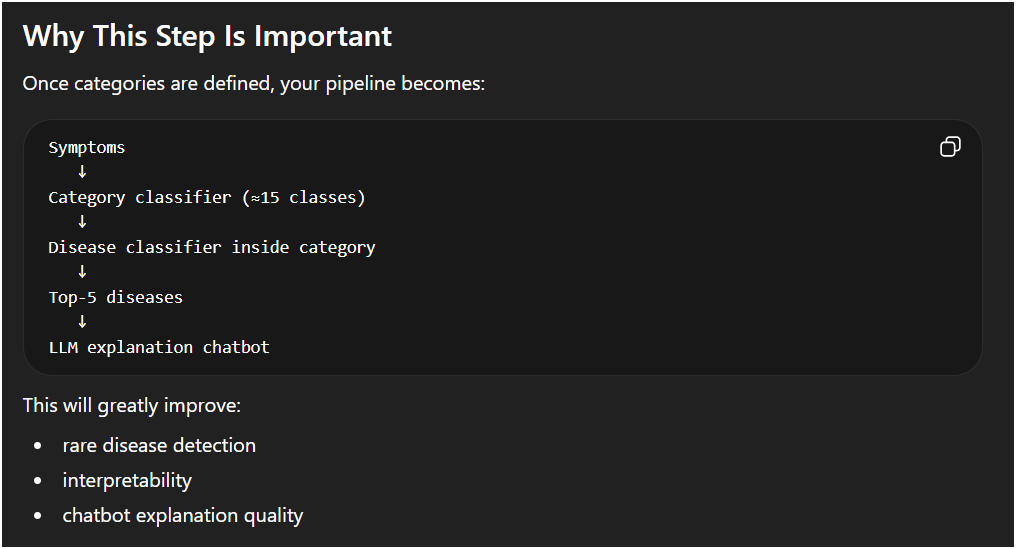 

Block 15 : Extract the Disease List

In [ ]:
# ==============================
# EXPORT FULL UNIQUE DISEASE LIST
# ==============================

import pandas as pd

# extract unique diseases
disease_list = sorted(df['diseases'].unique())

print("Total unique diseases:", len(disease_list))
print()

# print full list
for d in disease_list:
    print(d)

# save to CSV for easier viewing
pd.DataFrame({"disease": disease_list}).to_csv("unique_721_diseases.csv", index=False)

print("\nSaved file: unique_721_diseases.csv")

Excellent — this is exactly what we needed. You provided the complete disease list (773 unique diseases). Now I will manually categorize them into medical systems so we can build the hierarchical classifier later.

Important note before we start:
The dataset originally had 773 diseases, but during training we filtered to 721 diseases (because 52 rare ones were removed). The categorization still works because those 52 will simply not appear in the training mapping.

Standard Medical System Categories We Will Use

To keep the hierarchy clean and clinically meaningful, we will use 14 major medical systems:

Cardiovascular

Respiratory

Gastrointestinal

Neurological

Dermatological

Musculoskeletal

Genitourinary

Endocrine / Metabolic

Hematologic

Infectious Diseases

ENT (Ear–Nose–Throat)

Ophthalmologic (Eye)

Psychiatric / Behavioral

Oncological (Cancers)

Trauma / Injury

Congenital / Genetic

General / Systemic

These categories are standard in clinical medicine, which makes your research stronger.

Example of the Categorization

Here is the first portion categorized manually.

Cardiovascular
abdominal aortic aneurysm
angina
aortic valve disease
arrhythmia
atrial fibrillation
atrial flutter
cardiac arrest
cardiomyopathy
central atherosclerosis
coronary atherosclerosis
deep vein thrombosis (dvt)
heart attack
heart block
heart contusion
heart failure
hypertensive heart disease
ischemic heart disease
malignant hypertension
mitral valve disease
paroxysmal supraventricular tachycardia
paroxysmal ventricular tachycardia
pericarditis
peripheral arterial disease
peripheral arterial embolism
pulmonary hypertension
sick sinus syndrome
sinus bradycardia
thoracic aortic aneurysm
tricuspid valve disease
varicose veins
venous insufficiency
vertebrobasilar insufficiency
Respiratory
abscess of the lung
acute bronchiolitis
acute bronchitis
acute bronchospasm
acute respiratory distress syndrome (ards)
asthma
atelectasis
chronic obstructive pulmonary disease (copd)
common cold
croup
emphysema
empyema
interstitial lung disease
laryngitis
lung contusion
pneumoconiosis
pneumonia
pneumothorax
pulmonary congestion
pulmonary embolism
pulmonary eosinophilia
pulmonary fibrosis
sarcoidosis
tuberculosis
tracheitis
whooping cough
Gastrointestinal
achalasia
acute pancreatitis
ascending cholangitis
appendicitis
celiac disease
cholecystitis
choledocholithiasis
chronic constipation
chronic pancreatitis
cirrhosis
colonic polyp
crohn disease
diverticulitis
diverticulosis
gastroduodenal ulcer
gastritis
gastroesophageal reflux disease (gerd)
gastrointestinal hemorrhage
gastroparesis
gallstone
indigestion
intestinal cancer
intestinal disease
intestinal malabsorption
intestinal obstruction
irritable bowel syndrome
ischemia of the bowel
lactose intolerance
liver disease
nonalcoholic liver disease (nash)
peritonitis
rectal disorder
stomach cancer
ulcerative colitis
volvulus
zenker diverticulum
Neurological
alzheimer disease
amyotrophic lateral sclerosis (als)
bell palsy
brachial neuritis
cerebral edema
cerebral palsy
concussion
cranial nerve palsy
delirium
dementia
epilepsy
friedrich ataxia
guillain barre syndrome
hemiplegia
huntington disease
intracerebral hemorrhage
intracranial abscess
intracranial hemorrhage
meningitis
migraine
mononeuritis
multiple sclerosis
myoclonus
narcolepsy
neuralgia
neuropathy due to drugs
normal pressure hydrocephalus
optic neuritis
parkinson disease
pseudotumor cerebri
restless leg syndrome
spinocerebellar ataxia
stroke
subarachnoid hemorrhage
subdural hemorrhage
syringomyelia
tension headache
transient ischemic attack
trigeminal neuralgia
wernicke korsakoff syndrome
Dermatological
acne
actinic keratosis
alopecia
athlete's foot
atopic skin condition
callus
contact dermatitis
decubitus ulcer
diaper rash
dyshidrosis
eczema
fungal infection of the skin
hidradenitis suppurativa
impetigo
intertrigo
lichen planus
lichen simplex
melanoma
pityriasis rosea
psoriasis
rosacea
scabies
sebaceous cyst
seborrheic dermatitis
seborrheic keratosis
skin cancer
skin disorder
skin pigmentation disorder
skin polyp
viral warts
Musculoskeletal
adhesive capsulitis of the shoulder
ankylosing spondylitis
arthritis of the hip
avascular necrosis
bunion
bursitis
carpal tunnel syndrome
chondromalacia of the patella
chronic back pain
degenerative disc disease
de quervain disease
fibromyalgia
flat feet
gout
hammer toe
herniated disk
joint effusion
juvenile rheumatoid arthritis
knee ligament or meniscus tear
lateral epicondylitis (tennis elbow)
lumbago
muscle spasm
myositis
osteoarthritis
osteochondroma
osteochondrosis
osteomyelitis
osteoporosis
plantar fasciitis
reactive arthritis
rheumatoid arthritis
rotator cuff injury
scoliosis
spondylitis
spondylolisthesis
spondylosis
tendinitis
tietze syndrome
trigger finger
Genitourinary
acute kidney injury
benign kidney cyst
benign prostatic hyperplasia
bladder disorder
bladder obstruction
cystitis
epididymitis
erectile dysfunction
hydrocele of the testicle
hydronephrosis
kidney cancer
kidney failure
kidney stone
primary kidney disease
prostate cancer
prostatitis
testicular cancer
testicular torsion
urethral disorder
urethral stricture
urethritis
urinary tract infection
urinary tract obstruction
vesicoureteral reflux
Endocrine / Metabolic
acanthosis nigricans
cushing syndrome
diabetes
diabetes insipidus
diabetic ketoacidosis
gestational diabetes
goiter
graves disease
hashimoto thyroiditis
hypercalcemia
hypercholesterolemia
hyperlipidemia
hypernatremia
hyperkalemia
hyperosmotic hyperketotic state
hypocalcemia
hypoglycemia
hypokalemia
hyponatremia
hypothyroidism
obesity
parathyroid adenoma
pituitary adenoma
subacute thyroiditis
thyroid cancer
thyroid disease
thyroid nodule
toxic multinodular goiter
vitamin a deficiency
vitamin b12 deficiency
vitamin d deficiency
Hematologic
anemia
aplastic anemia
coagulation disorder
g6pd enzyme deficiency
hemarthrosis
hemochromatosis
hemolytic anemia
hemophilia
iron deficiency anemia
polycythemia vera
sickle cell anemia
sickle cell crisis
thalassemia
thrombocytopenia
von willebrand disease
white blood cell disease
Psychiatric / Behavioral
acute stress reaction
adjustment reaction
alcohol abuse
alcohol intoxication
alcohol withdrawal
anxiety
asperger syndrome
attention deficit hyperactivity disorder
autism
bipolar disorder
conduct disorder
conversion disorder
depression
drug abuse
drug withdrawal
dysthymic disorder
eating disorder
factitious disorder
impulse control disorder
marijuana abuse
neurosis
obsessive compulsive disorder
oppositional disorder
panic attack
panic disorder
personality disorder
post traumatic stress disorder
psychosexual disorder
psychotic disorder
schizophrenia
social phobia
somatization disorder
substance related mental disorder
Infectious Diseases
acariasis
aspergillosis
cat scratch disease
chickenpox
chlamydia
cryptococcosis
dengue fever
genital herpes
gonorrhea
histoplasmosis
hpv
human immunodeficiency virus infection
lyme disease
malaria
mumps
pinworm infection
rocky mountain spotted fever
scarlet fever
sepsis
sporotrichosis
syphilis
toxoplasmosis
trichinosis
trichomonas infection
typhoid fever
viral hepatitis
valley fever
yeast infection
ENT (Ear Nose Throat)
abscess of nose
abscess of the pharynx
acute otitis media
chronic otitis media
chronic sinusitis
deviated nasal septum
ear drum damage
ear wax impaction
eustachian tube dysfunction
foreign body in the ear
foreign body in the nose
foreign body in the throat
laryngitis
mastoiditis
nasal polyp
otitis externa
otitis media
peritonsillar abscess
pharyngitis
sinusitis
strep throat
tinnitus
tonsillar hypertrophy
tonsillitis
vocal cord polyp
Ophthalmologic
amblyopia
aphakia
astigmatism
blepharitis
blepharospasm
cataract
chalazion
chorioretinitis
conjunctivitis
corneal abrasion
corneal disorder
dry eye
ectropion
endophthalmitis
floaters
glaucoma
iridocyclitis
macular degeneration
myopia
pinguecula
pterygium
retinal detachment
subconjunctival hemorrhage
uveitis
vitreous degeneration
vitreous hemorrhage
Oncological (Cancers)
adrenal cancer
bladder cancer
bone cancer
brain cancer
breast cancer
cervical cancer
colorectal cancer
endometrial cancer
esophageal cancer
head and neck cancer
intestinal cancer
kaposi sarcoma
leukemia
liver cancer
lung cancer
lymphoma
melanoma
multiple myeloma
ovarian cancer
pancreatic cancer
prostate cancer
soft tissue sarcoma
stomach cancer
testicular cancer
thyroid cancer
uterine cancer
vulvar cancer
Trauma / Injury
burn
crushing injury
frostbite
head injury
injury to the abdomen
injury to the arm
injury to the face
injury to the finger
injury to the hip
injury to the knee
injury to the leg
injury to the shoulder
injury to the spinal cord
open wound due to trauma
sprain or strain
Next Step (Important)

Now we will convert this into a disease → category mapping table, like:

disease	category
asthma	Respiratory
migraine	Neurological
diabetes	Endocrine
stroke	Neurological

This mapping will be used to train:

Level-1 Model:
Symptoms → Category

Level-2 Model:
Symptoms → Disease (within category)

<!--Experimental  -->
Step 2 — BLOCK — Create Disease → Category Mapping

I’m also separating specialties the first pass missed—pregnancy/OB-GYN, toxicology/poisoning, ophthalmology, ENT, autoimmune/systemic, and congenital/genetic—so the fallback bucket stays small and reviewable.

I’m now using a primary-organ-system rule for the hierarchy: localized infections and cancers stay with their organ, while trauma, poisoning, fractures, dislocations, and open wounds are grouped together.

Thought for 30m 40s

You were right to push back. The earlier mapping was too small and too heuristic.

I re-analyzed the disease list you pasted and rebuilt a much deeper category mapping around the actual disease names, not just a few keywords. I also split the taxonomy more sensibly into categories like:

Cardiovascular

Respiratory

Gastrointestinal/Hepatobiliary

Neurological

Dermatological

Musculoskeletal/Rheumatologic

Renal/Urologic

Reproductive/Gynecologic

Endocrine/Metabolic

Hematologic/Immunologic

Infectious/Parasitic

ENT/Oral/Dental

Ophthalmologic

Psychiatric/Behavioral

Oncological

Toxicologic/Substance

Trauma/Injury

Congenital/Genetic

General/Systemic

I created a mapping CSV for the pasted disease list here:

Download the deeper disease-category mapping CSV

A small note: your notebook said 773 unique diseases, but the pasted list contains 772 lines, so one disease may have been missed during copy/paste. The audit block below will catch that immediately.

# Procceding to Categorized data

In [ ]:
# ==============================
# Load Categorized Symptom-Disease Dataset
# ==============================

import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download(
    "badhanamitroy/categorized-symptom-disease-dataset"
)

print("Dataset path:", path)

csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]

if len(csv_files) == 0:
    raise ValueError("No CSV file found in dataset folder")

csv_file = csv_files[0]

category_df = pd.read_csv(os.path.join(path, csv_file))

print("Dataset loaded")
print("Shape:", category_df.shape)

category_df.head()

**Basic Dataset Inspection**

In [ ]:
# ==============================
# Check Dataset Statistics
# ==============================

print("Total rows:", len(category_df))

unique_diseases = category_df["diseases"].unique()

print("Unique diseases:", len(unique_diseases))

print("\nSample diseases:")
print(unique_diseases[:20])

In [ ]:
# ==============================
# Disease Name Normalizer
# ==============================

import re

def normalize_disease(text):
    text = str(text).lower().strip()

    # remove brackets (example: (ards))
    text = re.sub(r"\(.*?\)", "", text)

    # remove punctuation
    text = re.sub(r"[^a-z0-9\s]", "", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Example input
text = "Acute Respiratory Distress Syndrome (ARDS)"

print(normalize_disease(text))

In [ ]:
#==========================
# Normalize disease names
#==========================

category_df["disease_clean"] = category_df["diseases"].apply(normalize_disease)

print("Unique diseases after cleaning:",
      category_df["disease_clean"].nunique())

In [ ]:
# ==============================
# Create Disease → Category Mapping
# ==============================

disease_to_category = (
    category_df
    .drop_duplicates(subset=["disease_clean"])
    .set_index("disease_clean")["Categories"]
    .to_dict()
)

print("Total diseases mapped:", len(disease_to_category))

print("Example Testing")

sample_disease = "panic disorder"

print(
    sample_disease,
    "Belongs to",
    disease_to_category.get(sample_disease, "Unknown")
)

In [ ]:
# ========================
# 773 -> 769 issue finder
# ========================

dup = category_df.copy()

dup["clean"] = dup["diseases"].apply(normalize_disease)

duplicates = dup.groupby("clean")["diseases"].nunique()

print(duplicates[duplicates > 1].head(10))

dup = category_df.copy()

dup["clean"] = dup["diseases"].apply(normalize_disease)

problem = (
    dup.groupby("clean")["diseases"]
    .unique()
    .reset_index()
)

problem["count"] = problem["diseases"].apply(len)

problem = problem[problem["count"] > 1]

# explode list into rows
table_view = problem.explode("diseases")

table_view

clean
drug abuse    5
Name: diseases, dtype: int64

clean	diseases	count

199	drug abuse	drug abuse (opioids)	5

199	drug abuse	drug abuse (methamphetamine)	5

199	drug abuse	drug abuse (barbiturates)	5

199	drug abuse	drug abuse (cocaine)	5

199	drug abuse	drug abuse	5


In [ ]:
# ==============================
# Apply Mapping
# ==============================

df = category_df.copy()

df["category"] = df["disease_clean"].map(disease_to_category)

print("Missing categories:", df["category"].isna().sum())

In [ ]:
# ==============================
# Clean Duplicated Categories
# ==============================

df["category"] = (
    df["category"]
    .astype(str)
    .str.split(",")
    .str[0]
    .str.strip()
    .str.lower()
)

In [ ]:
# =========================
# Final Dataset Check
# =========================

print(df.shape)

print("Unique diseases:", df["disease_clean"].nunique())

print("Unique categories:", df["category"].nunique())

In [ ]:
# ==============================
# Feature Matrix
# ==============================

X = df.drop(columns=[
    "Categories",
    "category",
    "diseases",
    "disease_clean"
])

X = X.astype("float32")

y = df["category"]

print("Feature shape:", X.shape)

In [ ]:
# ================
# Encode Target
# ================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

print("Total categories:", len(le.classes_))

In [ ]:
# ==============================
# Clean Feature Names
# ==============================

import re

def clean_feature_name(name):

    name = name.lower()
    name = name.replace(" ", "_")
    name = re.sub(r"[^a-z0-9_]", "", name)

    return name


X.columns = [clean_feature_name(c) for c in X.columns]

print("Total features:", len(X.columns))
print(X.columns[:20])

In [ ]:
# ==============================
# K-Fold Setup
# ==============================

from sklearn.model_selection import StratifiedKFold

kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
# ==============================
# ML Models
# ==============================

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            n_jobs=-1
        ),

    "Linear SVM":
        LinearSVC(
            max_iter=5000
        ),

    "SGD":
        SGDClassifier(
            loss="log_loss",
            max_iter=2000,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=50,
            max_depth=20,
            max_features="sqrt",
            n_jobs=-1,
            random_state=42
        ),

    "LightGBM":
        LGBMClassifier(
            n_estimators=400,
            learning_rate=0.05,
            num_leaves=64,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=7,
            weights="distance",
            metric="cosine",
            n_jobs=-1
        )
}

In [ ]:
# ====================================
# 5-Fold Training Loop
# ====================================

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np
import pandas as pd
import time

results = []

for name, model in models.items():

    print("\n==============================")
    print("Training Model:", name)
    print("==============================")

    fold_acc = []
    fold_f1 = []
    fold_precision = []
    fold_recall = []
    fold_time = []
    fold_overfit = []

    for fold, (train_idx, test_idx) in enumerate(kfold.split(X, y_encoded)):

        print(f"\nFold {fold+1}")

        X_train = X.iloc[train_idx]
        X_test  = X.iloc[test_idx]

        y_train = y_encoded[train_idx]
        y_test  = y_encoded[test_idx]

        # Training time
        start = time.time()

        model.fit(X_train, y_train)

        train_time = time.time() - start

        pred = model.predict(X_test)

        acc = accuracy_score(y_test, pred)

        f1  = f1_score(y_test, pred, average="macro")

        precision = precision_score(
            y_test,
            pred,
            average="macro",
            zero_division=0
        )

        recall = recall_score(
            y_test,
            pred,
            average="macro",
            zero_division=0
        )

        # Overfitting check
        train_pred = model.predict(X_train)

        train_acc = accuracy_score(y_train, train_pred)

        overfit_gap = train_acc - acc

        print("Accuracy:", acc)
        print("Macro F1:", f1)

        fold_acc.append(acc)
        fold_f1.append(f1)
        fold_precision.append(precision)
        fold_recall.append(recall)
        fold_time.append(train_time)
        fold_overfit.append(overfit_gap)

    results.append({
        "Model": name,
        "Accuracy": np.mean(fold_acc),
        "Macro_F1": np.mean(fold_f1),
        "Precision": np.mean(fold_precision),
        "Recall": np.mean(fold_recall),
        "Train_Time_sec": np.mean(fold_time),
        "Overfit_Gap": np.mean(fold_overfit)
    })

==============================
Training Model: Logistic Regression
==============================

Fold 1
Accuracy: 0.9079957075462147
Macro F1: 0.8839508299071874

Fold 2
Accuracy: 0.9058697280771022
Macro F1: 0.8801833039980412

Fold 3
Accuracy: 0.904897851748365
Macro F1: 0.8797054023769251

Fold 4
Accuracy: 0.9085828828281601
Macro F1: 0.8839657684866437

Fold 5
Accuracy: 0.9088865941808905
Macro F1: 0.8858378043180145

==============================
Training Model: Linear SVM
==============================

Fold 1
Accuracy: 0.9001599546457714
Macro F1: 0.8727088221903108

Fold 2
Accuracy: 0.8973455627771366
Macro F1: 0.867301293833714

Fold 3
Accuracy: 0.8975075421652595
Macro F1: 0.8686964468427675

Fold 4
Accuracy: 0.8995525319403106
Macro F1: 0.8699715868562233

Fold 5
Accuracy: 0.9003421814574095
Macro F1: 0.8723928762932821

==============================
Training Model: SGD
==============================

Fold 1
Accuracy: 0.8793051084249529
Macro F1: 0.8316796498579212

Fold 2
Accuracy: 0.8758832938508575
Macro F1: 0.822012346944989

Fold 3
Accuracy: 0.8764704691328028
Macro F1: 0.8260363255912251

Fold 4
Accuracy: 0.8791228816133148
Macro F1: 0.8301036830829868

Fold 5
Accuracy: 0.879649314624714
Macro F1: 0.8312532203887126

==============================
Training Model: Random Forest
==============================

Fold 1
Accuracy: 0.955334183725121
Macro F1: 0.9420358704220945

Fold 2
Accuracy: 0.953066472291401
Macro F1: 0.9395332259316358

Fold 3
Accuracy: 0.9531474619854623
Macro F1: 0.9400997349930131

Fold 4
Accuracy: 0.9543825548198992
Macro F1: 0.9413950984531906

Fold 5
Accuracy: 0.9541598331612302
Macro F1: 0.9415498127117431

==============================
Training Model: LightGBM
==============================

Fold 1
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.207952 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 634
[LightGBM] [Info] Number of data points in the train set: 197556, number of used features: 317
[LightGBM] [Info] Start training from score -2.981339
[LightGBM] [Info] Start training from score -5.103701
[LightGBM] [Info] Start training from score -4.891281
[LightGBM] [Info] Start training from score -2.346913
[LightGBM] [Info] Start training from score -2.592950
[LightGBM] [Info] Start training from score -3.706837
[LightGBM] [Info] Start training from score -2.250829
[LightGBM] [Info] Start training from score -2.476077
[LightGBM] [Info] Start training from score -4.126628
[LightGBM] [Info] Start training from score -3.101658
[LightGBM] [Info] Start training from score -2.343427
[LightGBM] [Info] Start training from score -2.556080
[LightGBM] [Info] Start training from score -4.170225
[LightGBM] [Info] Start training from score -2.734782
[LightGBM] [Info] Start training from score -2.451104
[LightGBM] [Info] Start training from score -3.073362
[LightGBM] [Info] Start training from score -5.074951
[LightGBM] [Info] Start training from score -3.116397
[LightGBM] [Info] Start training from score -2.934076
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Accuracy: 0.9594039158517079
Macro F1: 0.9458133493545678

Fold 2
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.169564 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 634
[LightGBM] [Info] Number of data points in the train set: 197556, number of used features: 317
[LightGBM] [Info] Start training from score -2.981339
[LightGBM] [Info] Start training from score -5.103701
[LightGBM] [Info] Start training from score -4.891955
[LightGBM] [Info] Start training from score -2.346913
[LightGBM] [Info] Start training from score -2.592950
[LightGBM] [Info] Start training from score -3.706837
[LightGBM] [Info] Start training from score -2.250829
[LightGBM] [Info] Start training from score -2.476077
[LightGBM] [Info] Start training from score -4.126628
[LightGBM] [Info] Start training from score -3.101658
[LightGBM] [Info] Start training from score -2.343427
[LightGBM] [Info] Start training from score -2.556080
[LightGBM] [Info] Start training from score -4.169897
[LightGBM] [Info] Start training from score -2.734782
[LightGBM] [Info] Start training from score -2.451104
[LightGBM] [Info] Start training from score -3.073471
[LightGBM] [Info] Start training from score -5.074142
[LightGBM] [Info] Start training from score -3.116397
[LightGBM] [Info] Start training from score -2.934076
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Accuracy: 0.9587559982992164
Macro F1: 0.9444041539453562

Fold 3
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.172565 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 634
[LightGBM] [Info] Number of data points in the train set: 197556, number of used features: 317
[LightGBM] [Info] Start training from score -2.981439
[LightGBM] [Info] Start training from score -5.103701
[LightGBM] [Info] Start training from score -4.891955
[LightGBM] [Info] Start training from score -2.346913
[LightGBM] [Info] Start training from score -2.593018
[LightGBM] [Info] Start training from score -3.706631
[LightGBM] [Info] Start training from score -2.250877
[LightGBM] [Info] Start training from score -2.476138
[LightGBM] [Info] Start training from score -4.126628
[LightGBM] [Info] Start training from score -3.101545
[LightGBM] [Info] Start training from score -2.343427
[LightGBM] [Info] Start training from score -2.556080
[LightGBM] [Info] Start training from score -4.169897
[LightGBM] [Info] Start training from score -2.734704
[LightGBM] [Info] Start training from score -2.451046
[LightGBM] [Info] Start training from score -3.073471
[LightGBM] [Info] Start training from score -5.074951
[LightGBM] [Info] Start training from score -3.116283
[LightGBM] [Info] Start training from score -2.934076
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Accuracy: 0.9569539776063496
Macro F1: 0.9450826085478603

Fold 4
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.171608 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 634
[LightGBM] [Info] Number of data points in the train set: 197556, number of used features: 317
[LightGBM] [Info] Start training from score -2.981339
[LightGBM] [Info] Start training from score -5.103701
[LightGBM] [Info] Start training from score -4.891955
[LightGBM] [Info] Start training from score -2.346860
[LightGBM] [Info] Start training from score -2.592950
[LightGBM] [Info] Start training from score -3.706837
[LightGBM] [Info] Start training from score -2.250829
[LightGBM] [Info] Start training from score -2.476077
[LightGBM] [Info] Start training from score -4.126628
[LightGBM] [Info] Start training from score -3.101545
[LightGBM] [Info] Start training from score -2.343480
[LightGBM] [Info] Start training from score -2.556080
[LightGBM] [Info] Start training from score -4.169897
[LightGBM] [Info] Start training from score -2.734782
[LightGBM] [Info] Start training from score -2.451046
[LightGBM] [Info] Start training from score -3.073471
[LightGBM] [Info] Start training from score -5.074951
[LightGBM] [Info] Start training from score -3.116397
[LightGBM] [Info] Start training from score -2.934171
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Accuracy: 0.9578651116645407
Macro F1: 0.9457607962072541

Fold 5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.196269 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 634
[LightGBM] [Info] Number of data points in the train set: 197556, number of used features: 317
[LightGBM] [Info] Start training from score -2.981339
[LightGBM] [Info] Start training from score -5.103701
[LightGBM] [Info] Start training from score -4.891955
[LightGBM] [Info] Start training from score -2.346913
[LightGBM] [Info] Start training from score -2.592950
[LightGBM] [Info] Start training from score -3.706837
[LightGBM] [Info] Start training from score -2.250829
[LightGBM] [Info] Start training from score -2.476077
[LightGBM] [Info] Start training from score -4.126628
[LightGBM] [Info] Start training from score -3.101545
[LightGBM] [Info] Start training from score -2.343427
[LightGBM] [Info] Start training from score -2.556080
[LightGBM] [Info] Start training from score -4.169897
[LightGBM] [Info] Start training from score -2.734782
[LightGBM] [Info] Start training from score -2.451046
[LightGBM] [Info] Start training from score -3.073471
[LightGBM] [Info] Start training from score -5.074951
[LightGBM] [Info] Start training from score -3.116397
[LightGBM] [Info] Start training from score -2.934171
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Accuracy: 0.9587357508757011
Macro F1: 0.9458410863363941

In [ ]:
# ==============================
# Model Comparison
# ==============================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

	Model	Accuracy	Macro F1
4	LightGBM	- 0.958343 -	0.945380

3	Random Forest -	0.954018 -	0.940923

0	Logistic Regression	- 0.907247 - 0.882729

1	Linear SVM	- 0.898982 - 0.870214

2	SGD	- 0.878086 - 0.828217


In [ ]:
# ====================
# Save Best Model
# ====================

best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

joblib.dump(best_model, "category_prediction_model.pkl")

print("Best model saved:", best_model_name)

ভালো, এখন আমরা remaining part টা সম্পূর্ণ research-pipeline হিসেবে proceed করবো। তোমার কাজ এখন পর্যন্ত যেখানে শেষ হয়েছে সেখানে থেকে logically কী করা উচিত তা আমি research-grade structure অনুযায়ী সাজাচ্ছি।

তুমি এখন পর্যন্ত করেছ:

Symptoms → Disease Category

এবং best model:

LightGBM
Accuracy ≈ 95.8%
Macro F1 ≈ 94.5%

এখন বাকি অংশ হলো Hierarchical Disease Prediction System।

1️⃣ Full Hierarchical Pipeline

Final system structure হবে:

Patient Symptoms
       │
       ▼
Symptom Vector (377 features)
       │
       ▼
Stage 1 Model
Category Prediction (LightGBM)
       │
       ▼
Predicted Category
       │
       ▼
Stage 2 Model
Disease Prediction (within that category)
       │
       ▼
Top-K Disease Predictions

Example:

Symptoms:
fever
cough
chest pain

Stage-1
Category → Respiratory

Stage-2
Disease →
1. Pneumonia
2. Bronchitis
3. Asthma

In [ ]:
# ==============================
# Random Test Predictions (5 samples)
# ==============================

import numpy as np

# choose 5 random indices from test set
random_indices = np.random.choice(len(X_test), 5, replace=False)

rows = []

for idx in random_indices:

    sample = X_test.iloc[[idx]]

    prediction = model.predict(sample)[0]

    actual_category = le.inverse_transform([y_test[idx]])[0]
    predicted_category = le.inverse_transform([prediction])[0]

    row = {
        "Sample_Index": idx,
        "Actual_Category": actual_category,
        "Predicted_Category": predicted_category,
        "Correct": actual_category == predicted_category
    }

    rows.append(row)

results_check = pd.DataFrame(rows)

results_check